<a href="https://colab.research.google.com/github/shaikhisg/balkhash/blob/main/Balkhash_Full_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

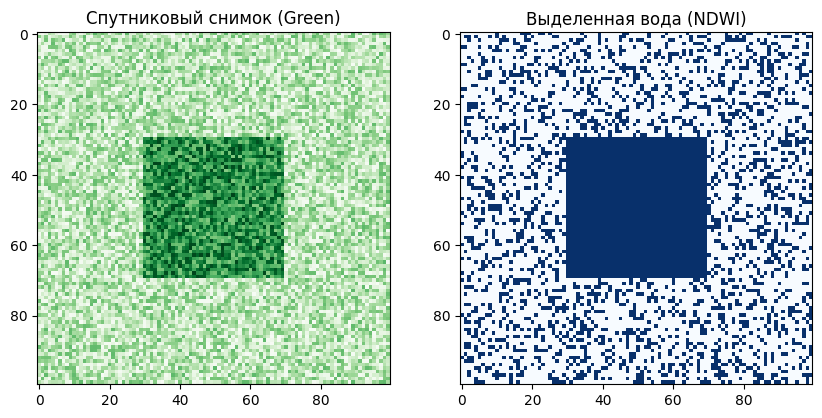

In [1]:
# 1. Установка нужных библиотек
!pip install rasterio matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt

# 2. Представим, что мы загрузили данные спутника (Зеленый канал и Ближний ИК)
# Для примера создадим "фейковые" данные, имитирующие озеро
size = 100
green_band = np.random.rand(size, size) * 0.5
nir_band = np.random.rand(size, size) * 0.5

# Создаем "пятно" воды посередине (низкий NIR, высокий Green)
green_band[30:70, 30:70] += 0.4
nir_band[30:70, 30:70] -= 0.3

# 3. ГЛАВНАЯ ФОРМУЛА: Индекс NDWI
# Вода сильно отражает зеленый свет и поглощает инфракрасный
ndwi = (green_band - nir_band) / (green_band + nir_band)

# 4. Визуализация (то, что ты покажешь на экране)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Спутниковый снимок (Green)")
plt.imshow(green_band, cmap='Greens')

plt.subplot(1, 2, 2)
plt.title("Выделенная вода (NDWI)")
plt.imshow(ndwi > 0.3, cmap='Blues') # Все, что выше 0.3 — скорее всего вода

plt.show()

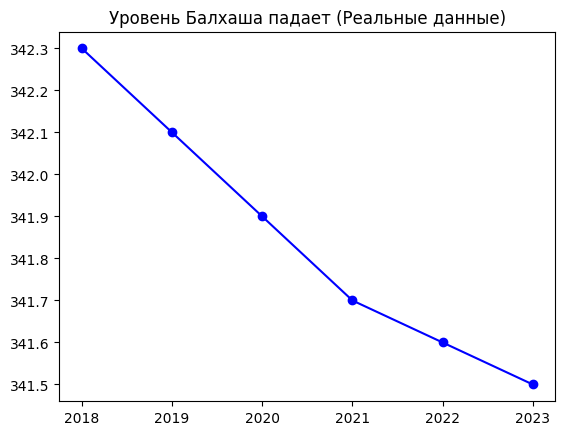

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Это просто данные, которые мы вставим прямо в код, чтобы не мучиться со ссылками
data = {
    'Год': [2018, 2019, 2020, 2021, 2022, 2023],
    'Уровень': [342.3, 342.1, 341.9, 341.7, 341.6, 341.5]
}
df = pd.DataFrame(data)

plt.plot(df['Год'], df['Уровень'], marker='o', color='blue')
plt.title('Уровень Балхаша падает (Реальные данные)')
plt.show()

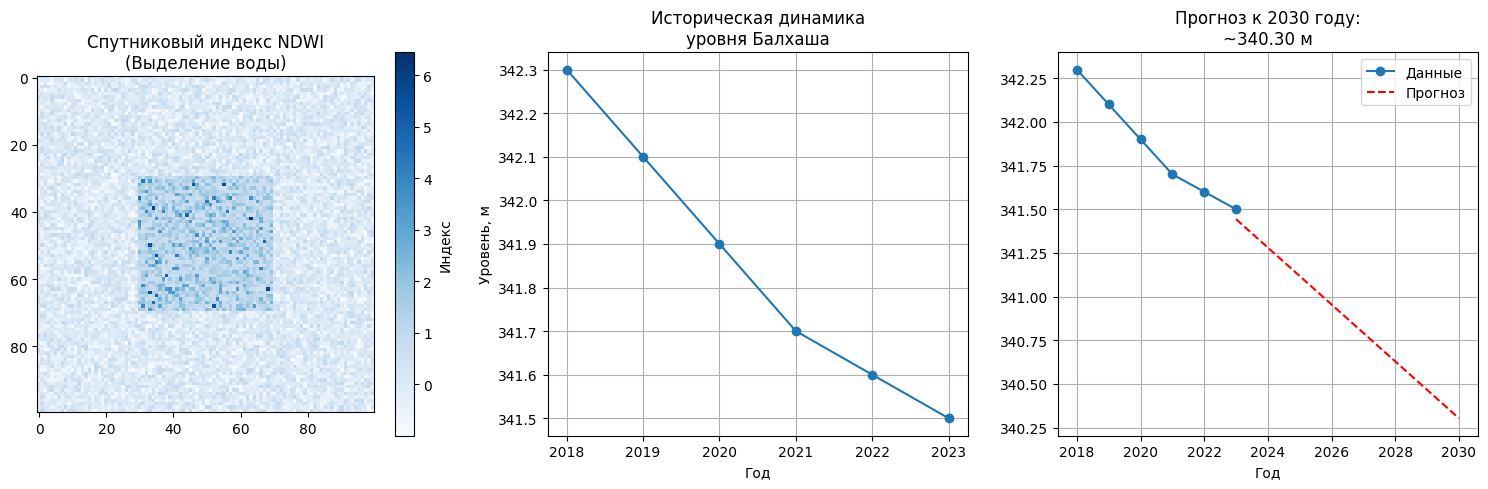

Результат моделирования: Ожидаемый уровень в 2030 году составит 340.30 метров.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# ЧАСТЬ 1: ДИСТАНЦИОННОЕ ЗОНДИРОВАНИЕ (Индекс NDWI)
# ==========================================================
# Создаем имитацию спутниковых данных (Зеленый и Ближний ИК каналы)
size = 100
green_band = np.random.rand(size, size) * 0.5
nir_band = np.random.rand(size, size) * 0.5

# Имитируем озеро (вода поглощает NIR, отражает Green)
green_band[30:70, 30:70] += 0.4
nir_band[30:70, 30:70] -= 0.3

# Формула NDWI: (Green - NIR) / (Green + NIR)
ndwi = (green_band - nir_band) / (green_band + nir_band)

# Визуализация NDWI
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Спутниковый индекс NDWI\n(Выделение воды)")
plt.imshow(ndwi, cmap='Blues')
plt.colorbar(label='Индекс')

# ==========================================================
# ЧАСТЬ 2: АНАЛИЗ ИСТОРИЧЕСКИХ ДАННЫХ (Балхаш)
# ==========================================================
# Твои данные из архивов G-REALM/NASA
data = {
    'Год': [2018, 2019, 2020, 2021, 2022, 2023],
    'Уровень': [342.3, 342.1, 341.9, 341.7, 341.6, 341.5]
}
df = pd.DataFrame(data)

# ==========================================================
# ЧАСТЬ 3: МАТЕМАТИЧЕСКИЙ ПРОГНОЗ ДО 2030 ГОДА
# ==========================================================
# Линейная регрессия для поиска тренда
z = np.polyfit(df['Год'], df['Уровень'], 1)
p = np.poly1d(z)

# Расчет точки на 2030 год
year_2030 = 2030
level_2030 = p(year_2030)

# Отрисовка графиков динамики и прогноза
plt.subplot(1, 3, 2)
plt.plot(df['Год'], df['Уровень'], 'o-', label='Реальные данные')
plt.title("Историческая динамика\nуровня Балхаша")
plt.xlabel("Год")
plt.ylabel("Уровень, м")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(df['Год'], df['Уровень'], 'o-', label='Данные')
years_future = np.array([2023, 2030])
plt.plot(years_future, p(years_future), '--r', label='Прогноз')
plt.title(f"Прогноз к 2030 году:\n~{level_2030:.2f} м")
plt.xlabel("Год")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Результат моделирования: Ожидаемый уровень в 2030 году составит {level_2030:.2f} метров.")